### Model 1: Fully Pooled Citywide Baseline

This notebook introduces a fully pooled baseline model, broken out by complaint category and day of the week (DOW).

In this setup, all observations share a common underlying mean, while still allowing for differences across days and categories.

In [2]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API",
    category=UserWarning,
)

In [3]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
from helpers import prep_the_data
import matplotlib.pyplot as plt
from helpers import ( prep_the_data, plot_panel_mu_by_weekday)

### Load + prepare data: 2021-2024 

In [4]:
df_puma = pd.read_parquet(
    "../data/processed/features/puma_noise_counts.parquet"
)


In [5]:
df_puma = prep_the_data(df_puma)

In [6]:
df_puma_2021__2024 = df_puma.loc[
    (df_puma["created_bucket"] >= "2021-01-01") &
    (df_puma["created_bucket"] <  "2024-12-31")
].copy()


### Aggregate City Complaint Counts by Day of Week and Category

To build a simple citywide baseline, we first aggregate complaints by day of week (DOW) and category, then average across time.

The goal here is straightforward:
get the typical number of complaints for each category–weekday combination.

In [7]:

# categorical key
keys = df_puma_2021__2024["dow_complaint"].astype(str)  # or dow_complaint if you didn't collapse
codes, dow_complaint_idx = np.unique(keys, return_inverse=True)

# Step 1: daily totals per category × weekday × date
daily = (
    df_puma_2021__2024
    .groupby(["dow_complaint", "created_bucket"], as_index=False)["complaint_count"]
    .sum()
)

# Step 2: average across days
agg_city = (
    daily
    .groupby("dow_complaint", as_index=False)["complaint_count"]
    .mean()
    .rename(columns={"complaint_count": "avg_daily_count"})
    .sort_values("dow_complaint")
    .reset_index(drop=True)
)



In [8]:
coords = {"dow_complaint": agg_city["dow_complaint"].astype(str).tolist()}

y = agg_city["avg_daily_count"].to_numpy().astype("float32")

### Construct fully pooled model 

**1. Prior on the log scale `log_mu`**

We model the complaint rate on the log scale. This keeps the model stable and avoids negative rates. Each `dow_complaint` gets its own parameter.  

```python
    log_mu = pm.Normal("log_mu", 0, 2, dims="dow_complaint")
```
    
**2. Convert to the natural scale**
```python
    mu = pm.Deterministic("mu", pm.math.exp(log_mu), dims="dow_complaint")
```
We exponentiate to get mu, the expected number of complaints.


**3. Likelihood (data generating process)**

We assume the observed complaint counts follow a Poisson distribution



In [9]:
with pm.Model(coords=coords) as model_pois_1:
    log_mu = pm.Normal("log_mu", 0, 2, dims="dow_complaint")
    mu = pm.Deterministic("mu", pm.math.exp(log_mu), dims="dow_complaint")

    y_obs = pm.Poisson("y_obs", mu=mu, observed=y)

    idata_pois_1 = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log_mu]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 21 seconds.


This table is a summary of the results from the Bayesian model. It helps us check two things:

**Did the sampler converge properly?**

**What rates did the model learn for each (NTA, weekday)?**

First, look at the sampling diagnostics:

**ess_bulk** and **ess_tail** should be large → this means we effectively have lots of independent samples

**r_hat** should be very close to 1.0 → this tells us the chains mixed well and converged

If these look good, we can trust the estimates.

Next, look at the parameter estimates:

**mean** → the model’s estimated average daily complaints (λ)

**sdv → uncertainty around that estimate

**hdi_3% / hdi_97%** → a credible interval (where the true rate likely falls)

So for example:

```
log_mu[ANIMAL__Friday]	  mean ≈ 2.478
```


This means the model believes that the log[mean]  on Friday typically sees about 2 complaints on Fridays, with some uncertainty around that number.

In [10]:
az.summary(idata_pois_1)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
log_mu[ANIMAL__Friday],2.479,0.288,1.973,3.014,0.004,0.005,4722.0,3009.0,1.0
log_mu[ANIMAL__Monday],2.548,0.283,1.967,3.024,0.004,0.005,5160.0,2678.0,1.0
log_mu[ANIMAL__Saturday],2.389,0.299,1.815,2.930,0.004,0.005,5715.0,2900.0,1.0
log_mu[ANIMAL__Sunday],2.478,0.277,1.960,3.002,0.004,0.005,5838.0,2932.0,1.0
log_mu[ANIMAL__Thursday],2.761,0.251,2.266,3.203,0.003,0.004,5832.0,3079.0,1.0
...,...,...,...,...,...,...,...,...,...
mu[SOCIAL_PARTY__Saturday],2443.134,50.769,2349.618,2538.877,0.743,0.788,4665.0,2948.0,1.0
mu[SOCIAL_PARTY__Sunday],2768.211,53.006,2669.477,2865.421,0.651,0.934,6661.0,2878.0,1.0
mu[SOCIAL_PARTY__Thursday],929.062,30.335,872.546,987.287,0.441,0.543,4715.0,3366.0,1.0
mu[SOCIAL_PARTY__Tuesday],925.456,30.249,869.514,981.178,0.394,0.479,5914.0,2936.0,1.0


In [11]:
with model_pois_1:
    ppc_pois_1 = pm.sample_posterior_predictive(
        idata_pois_1,
        var_names=["y_obs"],
        random_seed=42
    )

Sampling: [y_obs]


Output()

### Plot Average Daily noise complaint count by DOW

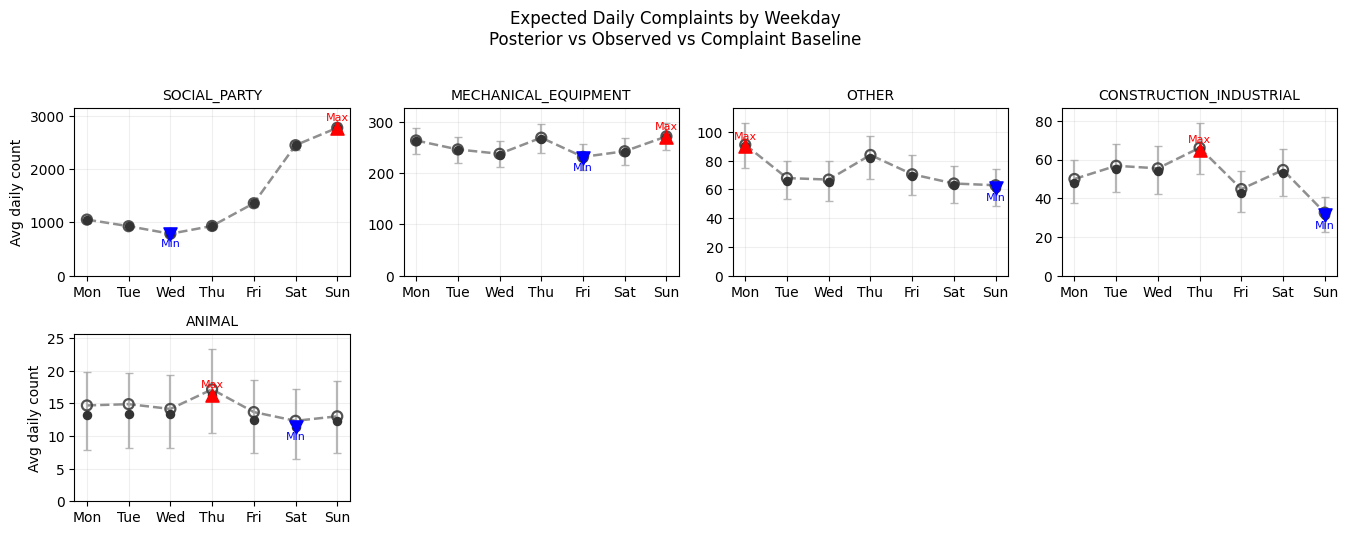

In [12]:
plot_panel_mu_by_weekday(
    idata_pois_1,
    agg_city=agg_city,
    top_n=None,   # or 5
    ncols=4,
    show_observed=True,
)